# 25SC2107E – Machine Learning (Skilling) Lab Manual
## Skilling Experiment 2: Titanic Survival — Preprocessing Pipeline and Cleaned Dataset
**Dataset:** Titanic | **Course Outcome:** CO1 | **Environment:** VS Code  
**Prepared by:** Dr. Omprakash Gottam, Dept. of ECE, KLEF Hyderabad

---
### 1.1 Aim
To turn the raw Titanic table from Experiment 1 into a clean table of numbers that a machine learning model can actually read — by removing bad columns, filling missing values, converting words into numbers and putting all numbers on the same scale — and to store every one of those steps inside a single object that can be saved and reused.

---


### Cell 1 — Import the libraries
Importing foundational libraries (`numpy`, `pandas`, `seaborn`, `matplotlib`, `joblib`) along with scikit-learn preprocessing and pipeline tools (`train_test_split`, `Pipeline`, `ColumnTransformer`, `SimpleImputer`, `StandardScaler`, `OneHotEncoder`, `OrdinalEncoder`).

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, MinMaxScaler

### Cell 2 — Load the data and drop the bad columns
We load the dataset using `sns.load_dataset("titanic")` and drop 7 problematic columns:
- `alive`: **Data leak** (directly duplicates target `survived`).
- `class`, `embark_town`, `who`, `adult_male`: Redundant duplicates of kept columns (`pclass`, `embarked`, `sex`).
- `deck`: Nearly empty (688 out of 891 missing values).
- `alone`: Rebuilt manually in Cell 3 for feature engineering practice.

In [2]:
titanic = sns.load_dataset("titanic")

leaks = ["alive", "who", "adult_male", "class", "embark_town", "alone", "deck"]
df = titanic.drop(columns=leaks)
print("Dataset shape after dropping leak and redundant columns:", df.shape)
df.head()

Dataset shape after dropping leak and redundant columns: (891, 8)


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


### Cell 3 — Rebuild the `is_alone` feature, then check it
We engineer `is_alone` from `sibsp` (siblings/spouses) and `parch` (parents/children) and verify that our formula perfectly matches seaborn's original `alone` column.
Then, we organize the remaining 8 columns into three distinct transformation groups: `numeric`, `categorical`, and `ordinal`.

In [3]:
df["is_alone"] = ((df["sibsp"] + df["parch"]) == 0).astype(int)

# Check if we rebuilt seaborn's "alone" column correctly
matches = (df["is_alone"] == titanic["alone"].astype(int)).all()
print("is_alone matches the original alone column:", matches)

numeric = ["age", "fare", "sibsp", "parch", "is_alone"]
categorical = ["sex", "embarked"]
ordinal = ["pclass"]

print("Numeric features:", numeric)
print("Categorical features:", categorical)
print("Ordinal features:", ordinal)

is_alone matches the original alone column: True
Numeric features: ['age', 'fare', 'sibsp', 'parch', 'is_alone']
Categorical features: ['sex', 'embarked']
Ordinal features: ['pclass']


### Cell 4 — Separate X and y, then split
We split the dataset into features ($X$) and target ($y$), then perform an $80/20$ stratified split (`train_test_split`).
*Crucial Rule:* Split **before** fitting any imputers or scalers to prevent data leakage from validation data into training statistics.

In [4]:
X = df.drop(columns="survived")
y = df["survived"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape, "| X_val shape:", X_val.shape)

X_train shape: (712, 8) | X_val shape: (179, 8)


### Cell 5 — Branch 1 & 2: Numeric and Categorical Pipelines
- **Numeric Branch:** Fills missing values with median (`SimpleImputer(strategy="median")`) and scales to zero mean/unit variance (`StandardScaler()`).
- **Categorical Branch:** Fills missing values with most frequent mode (`SimpleImputer(strategy="most_frequent")`) and one-hot encodes (`OneHotEncoder(handle_unknown="ignore")`).

In [5]:
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

### Cell 6 — Branch 3: Ordinal Pipeline
- **Ordinal Branch:** Imputes missing values with mode and encodes ranked values maintaining natural order ($1 < 2 < 3$) using `OrdinalEncoder(categories=[[1, 2, 3]])`.

In [6]:
ordinal_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=[[1, 2, 3]])),
])

### Cell 7 — Join the branches with ColumnTransformer and clean the data
We combine all three processing branches into a single `ColumnTransformer`.
We `fit_transform` on `X_train` and only `transform` on `X_val`.

In [7]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric),
    ("cat", categorical_pipe, categorical),
    ("ord", ordinal_pipe, ordinal),
])

X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)

print("Columns before vs after preprocessing:", X.shape[1], "->", X_train_t.shape[1])

Columns before vs after preprocessing: 8 -> 11


### Cell 8 — Put the names back on
Using `get_feature_names_out()`, we reconstruct a Pandas DataFrame with meaningful column names for inspection.

In [8]:
names = preprocessor.get_feature_names_out()
clean = pd.DataFrame(X_train_t, columns=names)
print("Cleaned feature columns count:", len(names))
clean.head()

Cleaned feature columns count: 11


,num__age,num__fare,num__sibsp,num__parch,num__is_alone,cat__sex_female,cat__sex_male,cat__embarked_C,cat__embarked_Q,cat__embarked_S,ord__pclass
0,-0.081135,0.513812,-0.465084,-0.466183,0.800346,0.0,1.0,0.0,0.0,1.0,2.0
1,-0.081135,-0.662563,-0.465084,-0.466183,0.800346,0.0,1.0,0.0,0.0,1.0,1.0
2,-0.081135,3.955399,-0.465084,-0.466183,0.800346,0.0,1.0,0.0,0.0,1.0,0.0
3,-0.887827,-0.467874,-0.465084,0.727782,-1.249460,1.0,0.0,0.0,0.0,1.0,2.0
4,0.110934,-0.115977,0.478335,0.727782,-1.249460,1.0,0.0,0.0,0.0,1.0,1.0


### Cell 9 — Plot Fare before cleaning
Histogram showing raw `fare` distribution (values range from 0 to 512, highly right-skewed).

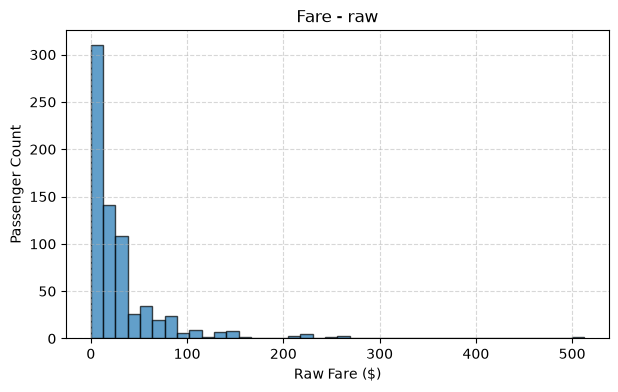

In [9]:
plt.figure(figsize=(7, 4))
plt.hist(X_train["fare"], bins=40, color="#1f77b4", edgecolor="black", alpha=0.7)
plt.title("Fare - raw")
plt.xlabel("Raw Fare ($)")
plt.ylabel("Passenger Count")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Cell 10 — Plot Fare after cleaning
Histogram showing `num__fare` after imputation and standard scaling (distribution shape is identical, but values are centered around mean 0).

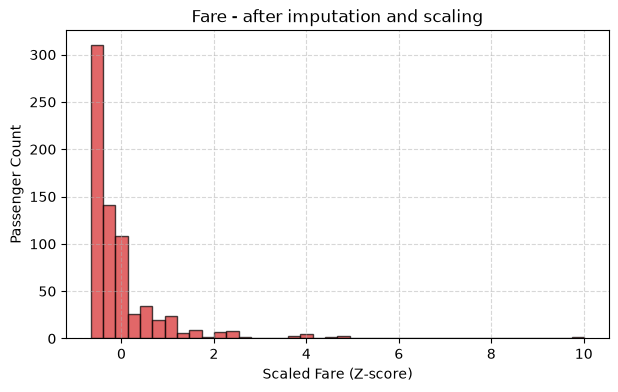

In [10]:
plt.figure(figsize=(7, 4))
plt.hist(clean["num__fare"], bins=40, color="#d62728", edgecolor="black", alpha=0.7)
plt.title("Fare - after imputation and scaling")
plt.xlabel("Scaled Fare (Z-score)")
plt.ylabel("Passenger Count")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Deliverable Functions & Model Serialization
Implementing `build_titanic_pipeline()` and `validate_pipeline()`, validating preprocessing integrity, and saving the fitted pipeline to `titanic_preprocessor.joblib`.

In [11]:
def build_titanic_pipeline():
    """Return the unfitted preprocessor built in Cells 5, 6 and 7."""
    return ColumnTransformer([
        ("num", numeric_pipe, numeric),
        ("cat", categorical_pipe, categorical),
        ("ord", ordinal_pipe, ordinal),
    ])

def validate_pipeline(pipeline, X_train, X_val):
    train = pipeline.transform(X_train)
    val = pipeline.transform(X_val)

    assert not np.isnan(train).any(), "missing values left in training data"
    assert train.shape[1] == val.shape[1], "train and val columns differ"
    assert train.shape[1] > 6, "too few features - encoders did not run"

    print("Pipeline validation PASSED")
    print("Features:", train.shape[1], " Train rows:", train.shape[0])

# Execute deliverables
pipeline = build_titanic_pipeline()
pipeline.fit(X_train)
validate_pipeline(pipeline, X_train, X_val)

# Save pipeline object
joblib.dump(pipeline, "titanic_preprocessor.joblib")
print("Fitted pipeline successfully saved to titanic_preprocessor.joblib")

Pipeline validation PASSED
Features: 11  Train rows: 712
Fitted pipeline successfully saved to titanic_preprocessor.joblib


---
## Self-Exploration & Viva Questions

### Q1: You dropped `alive` but kept `survived`. Both say the same thing. Why is one a cheat and the other the answer we want?
**Answer:**
`survived` is our target label ($y$). `alive` is a direct text translation of `survived` ("yes"/"no" vs 1/0). If `alive` is kept in $X$, a model will simply memorize `alive == 'yes' -> survived = 1`, achieving 100% training accuracy without learning any actual predictive patterns. This is called **target leakage** (or data leak).

---

### Q2: A classmate scales the whole dataset first and splits afterwards. Their score is higher than yours. Where did the extra marks come from, and why are they not real?
**Answer:**
Scaling before splitting causes **data leakage** from the validation set into the training set statistics (mean $\mu$ and standard deviation $\sigma$). The training scaling parameters include information from the validation rows (unseen exam questions). The resulting validation score is artificially inflated (overoptimistic) and will degrade when evaluated on true unseen real-world data.

---

### Q3: `age` is filled with the median, not the average. Why?
**Answer:**
`age` has a skewed distribution with potential outliers. The arithmetic mean is heavily influenced by extreme values, whereas the median is robust to outliers and represents the true central tendency of passenger ages far better.

---

### Q4: `pclass` uses `OrdinalEncoder` but `embarked` uses `OneHotEncoder`. What is it about the data that decides which one is correct?
**Answer:**
`pclass` possesses a natural inherent order ($1^{\text{st}} > 2^{\text{nd}} > 3^{\text{rd}}$), so `OrdinalEncoder` preserves ranking ($0, 1, 2$). `embarked` represents nominal categories (Ports Cherbourg, Queenstown, Southampton) without any numerical hierarchy. Using `OrdinalEncoder` on `embarked` would incorrectly state $S < C < Q$, which introduces false mathematical bias. Hence `OneHotEncoder` is used for nominal variables.

---

### Q5: You started with 8 columns and ended with 11. Explain where each of the 3 extra columns came from.
**Answer:**
The 8 raw input columns: `age`, `fare`, `sibsp`, `parch`, `is_alone`, `sex`, `embarked`, `pclass`.
- **Numeric (5):** `age`, `fare`, `sibsp`, `parch`, `is_alone` $\to$ 5 output columns.
- **Ordinal (1):** `pclass` $\to$ 1 output column ($0, 1, 2$).
- **Categorical (2):**
  - `sex` (female, male) $\to$ 2 one-hot columns (`sex_female`, `sex_male`).
  - `embarked` (C, Q, S) $\to$ 3 one-hot columns (`embarked_C`, `embarked_Q`, `embarked_S`).
Total transformed columns: $5 + 1 + (2 + 3) = 11$ columns ($8 + 3 = 11$).

---

### Q6: Why was `alone` dropped and then rebuilt as `is_alone`? What did the check in Cell 3 prove?
**Answer:**
`alone` was dropped to demonstrate feature engineering from fundamental raw fields (`sibsp` and `parch`). Rebuilding `is_alone = ((sibsp + parch) == 0).astype(int)` and asserting `(df["is_alone"] == titanic["alone"].astype(int)).all()` proved that our engineered feature logic matches the original calculated column with 100% precision.

---

### Q7: Explore: Change `handle_unknown="ignore"` to `"error"`, then pass a passenger whose port is `"X"`. What happens?
Let's run a test cell demonstrating the exception:


In [12]:
# Exploration Q7 Test
cat_pipe_error = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="error")),
])

prep_error = ColumnTransformer([
    ("num", numeric_pipe, numeric),
    ("cat", cat_pipe_error, categorical),
    ("ord", ordinal_pipe, ordinal),
])

prep_error.fit(X_train)

# Create mock unseen passenger with embarked = "X"
unseen_passenger = X_val.iloc[:1].copy()
unseen_passenger["embarked"] = "X"

try:
    prep_error.transform(unseen_passenger)
except ValueError as e:
    print("Caught expected ValueError with handle_unknown='error':")
    print(e)


Caught expected ValueError with handle_unknown='error':
Found unknown categories ['X'] in column 1 during transform


---
### Q8: Explore: Replace `StandardScaler` with `MinMaxScaler` and draw Cell 10 again. What changed, and what stayed the same?
Let's run a test comparing `StandardScaler` vs `MinMaxScaler` on `fare`:


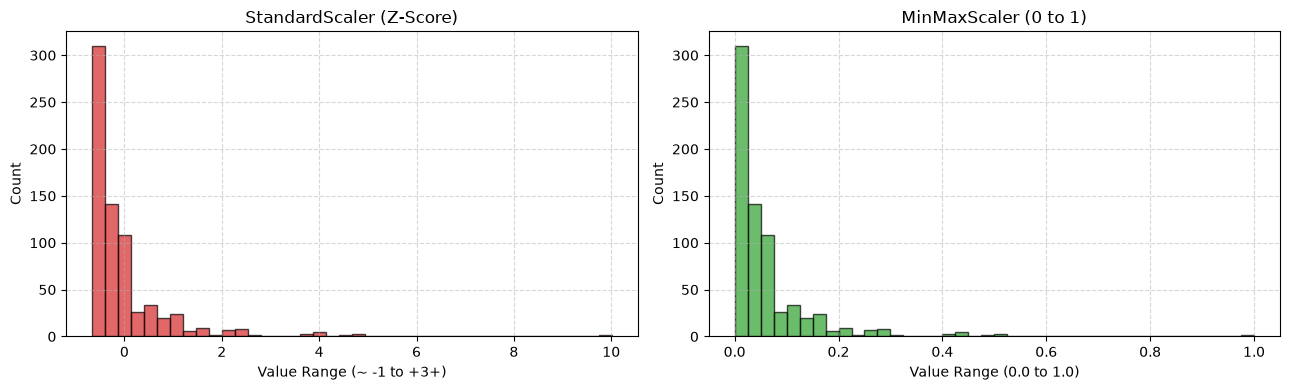

Comparison Summary:
- Stayed the same: Visual shape, right-skewness, bin ratios.
- Changed: Value boundaries (StandardScaler: mean=0, std=1; MinMaxScaler: min=0, max=1).


In [13]:
# Exploration Q8 Test
num_pipe_minmax = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", MinMaxScaler()),
])

prep_minmax = ColumnTransformer([
    ("num", num_pipe_minmax, numeric),
    ("cat", categorical_pipe, categorical),
    ("ord", ordinal_pipe, ordinal),
])

prep_minmax.fit(X_train)
X_train_minmax = prep_minmax.transform(X_train)
clean_minmax = pd.DataFrame(X_train_minmax, columns=names)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(clean["num__fare"], bins=40, color="#d62728", edgecolor="black", alpha=0.7)
axes[0].set_title("StandardScaler (Z-Score)")
axes[0].set_xlabel("Value Range (~ -1 to +3+)")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].hist(clean_minmax["num__fare"], bins=40, color="#2ca02c", edgecolor="black", alpha=0.7)
axes[1].set_title("MinMaxScaler (0 to 1)")
axes[1].set_xlabel("Value Range (0.0 to 1.0)")
axes[1].set_ylabel("Count")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print("Comparison Summary:")
print("- Stayed the same: Visual shape, right-skewness, bin ratios.")
print("- Changed: Value boundaries (StandardScaler: mean=0, std=1; MinMaxScaler: min=0, max=1).")